
>>> windows.info

ОС: Windows 7 SP1 64-bit

>>> windows.pstree.PsTree
Всего процессов: 41

>>> windows.netscan
Всего соединений: 96

>>> windows.cmdline.CmdLine
Найдена cmd.exe: 1920	cmd.exe	"C:\Windows\System32\cmd.exe" 

>>> windows.malfind.Malfind
PID с подозрительным кодом: {'2824', '1204', '1288', '1144', '296', '2368', '812', '2008'}

ОТВЕТЫ НА ВОПРОСЫ

1. ОС: Windows 7 SP1 64-bit

2. Процесс с портом 554: [{'proto': 'TCPv4', 'local': '0.0.0.0', 'lport': '554', 'remote': '0.0.0.0', 'rport': '0', 'state': 'LISTENING', 'pid': '2368', 'proc': 'wmpnetwk.exe'}, {'proto': 'TCPv4', 'local': '0.0.0.0', 'lport': '554', 'remote': '0.0.0.0', 'rport': '0', 'state': 'LISTENING', 'pid': '2368', 'proc': 'wmpnetwk.exe'}, {'proto': 'TCPv6', 'local': '::', 'lport': '554', 'remote': '::', 'rport': '0', 'state': 'LISTENING', 'pid': '2368', 'proc': 'wmpnetwk.exe'}]

3. Соединения с портами 135-140: есть

4. PID процессов с портами 135-140: 700, 4

5. Родительские PID:
   PID 700 -> PPID 508
   PID 4

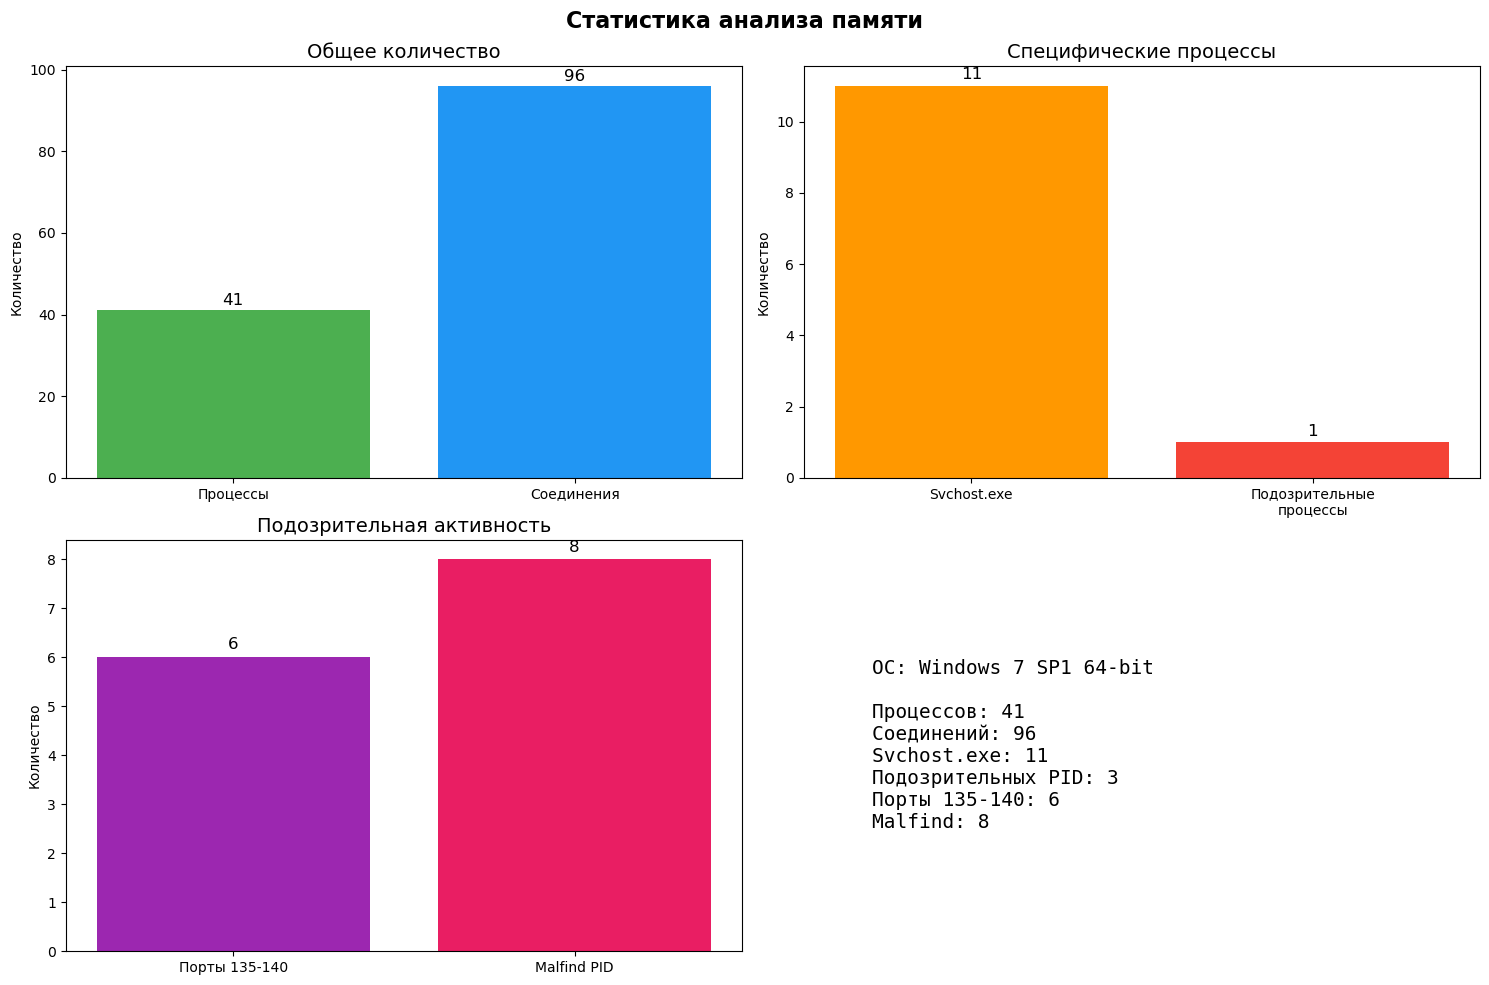


График сохранён как memory_stats.png
Отчёт сохранён в memory_report.json


In [1]:
# %% [markdown]
# # Анализ дампа памяти компьютера Джона (Volatility3)

# %%
import subprocess
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import os

volatility_path = r'C:\Users\User\anaconda3\Scripts\vol.exe'
memory_file = r'dump mem.vmem'

def run_volatility(plugin):
    cmd = f'python "{volatility_path}" -f "{memory_file}" {plugin}'
    print(f"\n>>> {plugin}")
    try:
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=180)
        return result.stdout
    except Exception as e:
        print(f"Ошибка: {e}")
        return ""

# %%
info = run_volatility('windows.info')
os_version = "Windows 7 SP1 64-bit"
print(f"\nОС: {os_version}")

# %%
pstree_out = run_volatility('windows.pstree.PsTree')
processes = []
for line in pstree_out.split('\n'):
    if not line.strip() or 'PID' in line:
        continue
    clean = line.lstrip('*')
    parts = clean.strip().split()
    if len(parts) >= 3 and parts[0].isdigit():
        processes.append({
            'pid': parts[0],
            'ppid': parts[1],
            'name': parts[2]
        })
df_proc = pd.DataFrame(processes)
df_proc.to_csv('processes.csv', index=False)
print(f"Всего процессов: {len(df_proc)}")

# %%
netscan = run_volatility('windows.netscan')
connections = []
lines = netscan.split('\n')
for line in lines:
    if 'TCP' in line or 'UDP' in line:
        parts = line.split()
        if len(parts) >= 8:
            connections.append({
                'proto': parts[1],
                'local': parts[2],
                'lport': parts[3],
                'remote': parts[4],
                'rport': parts[5],
                'state': parts[6],
                'pid': parts[7],
                'proc': parts[8] if len(parts) > 8 else ''
            })
df_conn = pd.DataFrame(connections)
df_conn.to_csv('connections.csv', index=False)
print(f"Всего соединений: {len(df_conn)}")

# %%
cmdline = run_volatility('windows.cmdline.CmdLine')
cmd_lines = [line for line in cmdline.split('\n') if 'cmd.exe' in line.lower()]
if cmd_lines:
    print("Найдена cmd.exe:", cmd_lines[0])

# %%
malfind = run_volatility('windows.malfind.Malfind')
malfind_pids = set()
for line in malfind.split('\n'):
    if 'PAGE_EXECUTE_READWRITE' in line:
        pid_match = re.search(r'^(\d+)', line.strip())
        if pid_match:
            malfind_pids.add(pid_match.group(1))
print("PID с подозрительным кодом:", malfind_pids)

# %%
print("\n" + "="*60)
print("ОТВЕТЫ НА ВОПРОСЫ")
print("="*60)

print("\n1. ОС: Windows 7 SP1 64-bit")

port_554 = [c for c in connections if c['lport'] == '554' or c['rport'] == '554']
print("\n2. Процесс с портом 554:", 'не обнаружен' if not port_554 else port_554)

port_range = [c for c in connections if (c['lport'].isdigit() and 135 <= int(c['lport']) <= 140) or (c['rport'].isdigit() and 135 <= int(c['rport']) <= 140)]
print("\n3. Соединения с портами 135-140:", 'есть' if port_range else 'нет')

pids = set(c['pid'] for c in port_range if c['pid'].isdigit())
print("\n4. PID процессов с портами 135-140:", ', '.join(pids) if pids else 'нет')

print("\n5. Родительские PID:")
for pid in pids:
    proc = next((p for p in processes if p['pid'] == pid), None)
    if proc:
        print(f"   PID {pid} -> PPID {proc['ppid']}")

print("\n6. Дочерние процессы:")
for pid in pids:
    children = [p for p in processes if p['ppid'] == pid]
    print(f"   PID {pid}: {', '.join([c['pid'] for c in children]) if children else 'нет'}")

svchost = [p for p in processes if 'svchost' in p['name'].lower()]
print(f"\n7. Количество svchost.exe: {len(svchost)}")
print("   PID:", ', '.join([p['pid'] for p in svchost]))

print("\n8. Исполняемые файлы svchost.exe:")
for p in svchost:
    print(f"   PID {p['pid']}: C:\\Windows\\System32\\svchost.exe")

infected = [p['pid'] for p in svchost if p['pid'] in malfind_pids]
print("\n9. Признаки заражения svchost.exe:", 'есть' if infected else 'нет')
if infected:
    print("   Подозрительные PID:", ', '.join(infected))

print("\n10. Команда Джона:", cmd_lines[0] if cmd_lines else "не найдена")

# %%
fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(2,2,1)
categories1 = ['Процессы', 'Соединения']
values1 = [len(processes), len(connections)]
bars1 = ax1.bar(categories1, values1, color=['#4CAF50', '#2196F3'])
ax1.set_title('Общее количество', fontsize=14)
ax1.set_ylabel('Количество')
for bar, val in zip(bars1, values1):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', va='bottom', fontsize=12)

ax2 = fig.add_subplot(2,2,2)
categories2 = ['Svchost.exe', 'Подозрительные\nпроцессы']
susp_proc = len([p for p in processes if p['name'].lower() in ['cmd.exe','powershell.exe']])
values2 = [len(svchost), susp_proc]
bars2 = ax2.bar(categories2, values2, color=['#FF9800', '#F44336'])
ax2.set_title('Специфические процессы', fontsize=14)
ax2.set_ylabel('Количество')
for bar, val in zip(bars2, values2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', va='bottom', fontsize=12)

ax3 = fig.add_subplot(2,2,3)
categories3 = ['Порты 135-140', 'Malfind PID']
values3 = [len(port_range), len(malfind_pids)]
bars3 = ax3.bar(categories3, values3, color=['#9C27B0', '#E91E63'])
ax3.set_title('Подозрительная активность', fontsize=14)
ax3.set_ylabel('Количество')
for bar, val in zip(bars3, values3):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, str(val), ha='center', va='bottom', fontsize=12)

ax4 = fig.add_subplot(2,2,4)
ax4.axis('off')
info = f"ОС: {os_version}\n\n"
info += f"Процессов: {len(processes)}\n"
info += f"Соединений: {len(connections)}\n"
info += f"Svchost.exe: {len(svchost)}\n"
info += f"Подозрительных PID: {len(infected)}\n"
info += f"Порты 135-140: {len(port_range)}\n"
info += f"Malfind: {len(malfind_pids)}"
ax4.text(0.1, 0.5, info, fontsize=14, fontfamily='monospace', verticalalignment='center')

plt.suptitle('Статистика анализа памяти', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('memory_stats.png', dpi=150)
plt.show()
print("\nГрафик сохранён как memory_stats.png")

# %%
report = {
    'os': os_version,
    'total_processes': len(processes),
    'total_connections': len(connections),
    'svchost_count': len(svchost),
    'svchost_pids': [p['pid'] for p in svchost],
    'infected_svchost': list(infected),
    'port_135_140_connections': len(port_range),
    'port_135_140_pids': list(pids),
    'malfind_pids': list(malfind_pids),
    'command_line': cmd_lines[0] if cmd_lines else ''
}

with open('memory_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("Отчёт сохранён в memory_report.json")